# Notebook 2: Data Cleaning, Pre-Processing & Dimensionality Reduction
---
**Goal:** Apply all the decisions made during EDA to produce a clean, scaled dataset. Every column drop and transformation in this notebook is justified by a specific EDA finding.

### Steps in this notebook:
1. Drop identity and irrelevant columns
2. Drop low-variance features identified in EDA
3. Handle missing values
4. Remove outliers using IQR
5. Scale features using StandardScaler
6. Save cleaned dataset

---
## Setup: Imports and Data Loading

Import all required libraries and load the raw training data. We confirm the shape matches what we saw in EDA (28,362 rows × 24 columns) before making any changes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style('whitegrid')

DATA_PATH = '/Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/train.csv'
df = pd.read_csv(DATA_PATH)

print(f'Raw data shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Raw data shape: (28362, 24)
Columns: ['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'topic', 'age']


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


---
## Step 1: Drop Identity and Irrelevant Columns

These columns can not be used by KMeans because they are either text or index values with no numeric meaning. Keeping these columns would cause errors or meaningless distance calculations in the clustering step.

In [19]:
cols_to_drop_identity = ['Unnamed: 0', 'lyrics', 'artist_name', 'track_name']
df_clean = df.drop(
    columns=[c for c in cols_to_drop_identity if c in df.columns]
)

print(f'Shape after dropping identity columns: {df_clean.shape}')
print(f'Remaining columns: {df_clean.columns.tolist()}')

Shape after dropping identity columns: (28362, 20)
Remaining columns: ['release_date', 'genre', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'topic', 'age']



**EDA justification:** The variance analysis in Notebook 1 identified four score columns with variance below 0.003. These columns are so heavily skewed toward zero that most songs look nearly identical on these dimensions. 

Columns being dropped and their variances:
- `shake the audience`: 0.00165
- `family/gospel`: 0.00176
- `family/spiritual`:  0.00260
- `dating`:  0.00274



In [20]:
# Drop the four lowest-variance score columns identified in EDA
# These features lack sufficient spread to contribute meaningful cluster separation
low_variance_cols = [
    'shake the audience',  # variance: 0.00165
    'family/gospel',       # variance: 0.00176
    'family/spiritual',    # variance: 0.00260
    'dating',              # variance: 0.00274
]

df_clean = df_clean.drop(
    columns=[c for c in low_variance_cols if c in df_clean.columns]
)

print(f'Shape after dropping low-variance columns: {df_clean.shape}')
print(f'Remaining columns: {df_clean.columns.tolist()}')

Shape after dropping low-variance columns: (28362, 16)
Remaining columns: ['release_date', 'genre', 'len', 'violence', 'world/life', 'night/time', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'sadness', 'feelings', 'topic', 'age']


---
## Step 3: Handle Missing Values

EDA confirmed zero null values across the entire dataset. We run the check again here on the cleaned dataframe as a verification step. If nulls are found at this stage, we drop those rows since the score columns come from a structured research paper and any null would indicate a data corruption issue rather than a systematic gap.

In [18]:
nulls = df_clean.isnull().sum()
print('Missing values per column:')
print(
    nulls[nulls > 0]
    if nulls.sum() > 0
    else 'No missing values confirmed'
)
print(f'\nTotal rows: {len(df_clean):,}')

Missing values per column:
No missing values confirmed

Total rows: 13,103


In [16]:
rows_before = len(df_clean)
df_clean = df_clean.dropna()
print(f'Rows before: {rows_before:,}')
print(f'Rows after:  {len(df_clean):,}')
print(f'Rows removed: {rows_before - len(df_clean)}')

Rows before: 13,103
Rows after:  13,103
Rows removed: 0


---
## Step 4: Remove Outliers Using IQR

Outliers are extreme values that sit far outside the normal range of a column. KMeans is sensitive to outliers because they can pull cluster centroids away from the true center of a group, distorting the results. So we have to account for that using the following method!

We use the **IQR (Interquartile Range) method**:
- IQR = the range of the middle 50% of values (Q3 − Q1)
- Any value more than 3× IQR beyond Q1 or Q3 is removed


In [15]:

score_cols_final = [
    'violence', 'world/life', 'night/time', 'romantic',
    'communication', 'obscene', 'music', 'movement/places',
    'light/visual perceptions', 'sadness', 'feelings'
]
score_cols_final = [c for c in score_cols_final if c in df_clean.columns]
print(f'Score columns entering the model ({len(score_cols_final)} total):')
print(score_cols_final)

Score columns entering the model (11 total):
['violence', 'world/life', 'night/time', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'sadness', 'feelings']


In [14]:
rows_before = len(df_clean)

for col in score_cols_final:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    df_clean = df_clean[
        (df_clean[col] >= lower) & (df_clean[col] <= upper)
    ]

rows_after = len(df_clean)
print(f'Rows before outlier removal: {rows_before:,}')
print(f'Rows after outlier removal:  {rows_after:,}')
print(f'Rows removed: {rows_before - rows_after:,}')

Rows before outlier removal: 17,172
Rows after outlier removal:  13,103
Rows removed: 4,069


---
## Step 5: Scale Features with StandardScaler

KMeans calculates the distance between every song and every cluster centroid. If one column has a much larger spread than another, it dominates those distance calculations. The other columns do not really influence e the result.

**EDA justification:** The variance analysis showed a 20× difference in spread between our strongest (`obscene`, variance 0.033) and weakest remaining features (`feelings`, variance 0.005). Without scaling, `obscene` would contribute 20× more than `feelings` to every distance calculation.

`StandardScaler` transforms each column to have **mean = 0** and **standard deviation = 1**, putting all features on equal footing. 

**Important:** We fit the scaler on the training data here and then save it so it can be used during modeling

In [13]:
# Fit StandardScaler on the training score columns
# transform() re-centers each column to mean=0, std=1
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[score_cols_final]),
    columns=score_cols_final,
    index=df_clean.index
)

print('Before scaling')
print(df_clean[score_cols_final[:3]].agg(['mean', 'std']).round(4))
print()
print('After scaling')
print(X_scaled[score_cols_final[:3]].agg(['mean', 'std']).round(4))

Before scaling
      violence  world/life  night/time
mean    0.1515      0.1520      0.0328
std     0.1912      0.1868      0.0551

After scaling
      violence  world/life  night/time
mean      -0.0         0.0        -0.0
std        1.0         1.0         1.0


### Before vs After Scaling Visualization

This side-by-side histogram shows the effect of StandardScaler on the `sadness` column. Scaling only shifts the x-axis so that 0 is now the mean and the spread is standardized to 1 standard deviation.

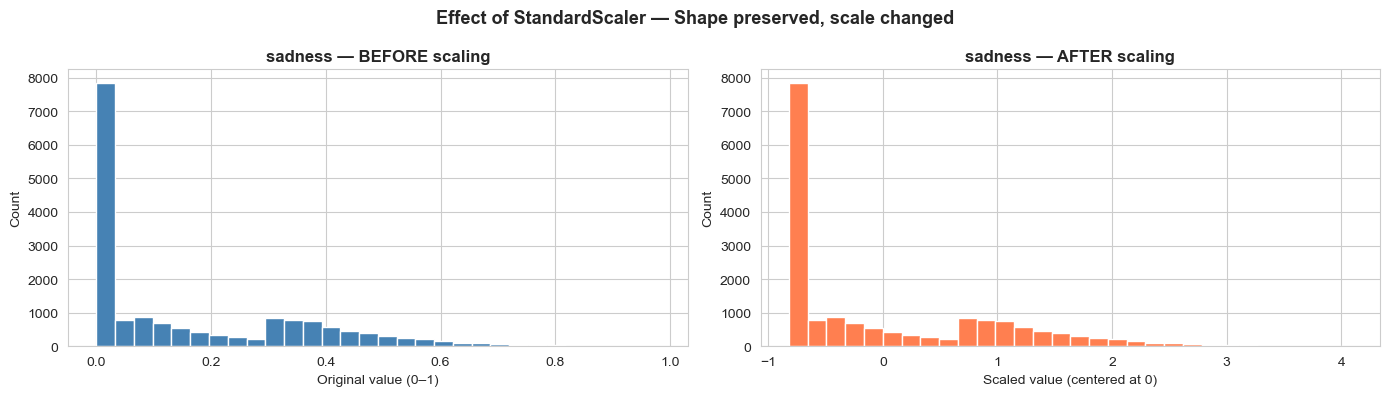

In [ ]:
col_to_show = 'sadness'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    df_clean[col_to_show], bins=30, color='steelblue', edgecolor='white'
)
axes[0].set_title(f'{col_to_show} — BEFORE scaling', fontweight='bold')
axes[0].set_xlabel('Original value (0–1)')
axes[0].set_ylabel('Count')

axes[1].hist(
    X_scaled[col_to_show], bins=30, color='coral', edgecolor='white'
)
axes[1].set_title(f'{col_to_show} — AFTER scaling', fontweight='bold')
axes[1].set_xlabel('Scaled value (centered at 0)')
axes[1].set_ylabel('Count')

plt.suptitle(
    'Effect of StandardScaler — Shape preserved, scale changed',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

**Finding:** The distribution shape is identical before and after scaling. StandardScaler does not alter the underlying pattern — it only ensures all columns contribute equally to the KMeans distance calculations.

---
## Step 6: Build Final Dataframe

We combine the label columns (`genre`, `topic`, `release_date`, `age`, `len`) with the scaled score columns. The label columns are retained so we can interpret cluster results in human terms after modeling — they are not fed into the clustering algorithm itself.

In [ ]:
label_cols = ['release_date', 'genre', 'topic', 'age', 'len']
label_cols = [c for c in label_cols if c in df_clean.columns]
df_final = pd.concat(
    [
        df_clean[label_cols].reset_index(drop=True),
        X_scaled.reset_index(drop=True)
    ],
    axis=1
)

print(f'Final cleaned dataframe shape: {df_final.shape}')
print(f'Label columns retained: {label_cols}')
print(f'Score columns scaled: {score_cols_final}')
df_final.head()

Final cleaned dataframe shape: (17172, 16)
Label columns retained: ['release_date', 'genre', 'topic', 'age', 'len']
Score columns scaled: ['violence', 'world/life', 'night/time', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'sadness', 'feelings']


,release_date,genre,topic,age,len,violence,world/life,night/time,romantic,communication,obscene,music,movement/places,light/visual perceptions,sadness,feelings
0,1950,pop,sadness,1.0,95,-0.458996,-0.810138,-0.585708,-0.103539,1.552523,-0.590340,0.268407,-0.537782,-0.584282,1.082532,3.114101
1,1950,pop,world/life,1.0,51,-0.286273,1.559984,-0.573254,-0.524649,-0.758953,-0.586082,1.875066,-0.527149,2.631132,-0.814562,-0.549741
2,1950,pop,violence,1.0,98,1.407499,-0.807705,0.749050,-0.530799,-0.760988,-0.587517,-0.511724,-0.530733,2.016986,-0.178845,-0.557046
3,1950,pop,world/life,1.0,179,-0.789811,1.176672,0.142955,-0.545965,2.617714,-0.591055,-0.523349,-0.539569,0.079116,-0.818571,3.302978
4,1950,pop,sadness,1.0,61,-0.256095,-0.807345,0.383310,-0.529011,0.036191,-0.587100,-0.510353,1.092989,-0.576372,2.334907,-0.554922


---
## Step 7: Save the Cleaned Dataset

We save the cleaned, scaled dataframe as `train_cleaned.csv`. This file is the input for Notebook 3 (Modeling). The scaler object is also saved using `pickle` so the same scaling parameters can be applied to the recommendation dataset in Notebook 3 without re fitting.

In [ ]:
import pickle
import os

OUTPUT_PATH = '/Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/train_cleaned.csv'
df_final.to_csv(OUTPUT_PATH, index=False)
print(f'Saved cleaned data to: {OUTPUT_PATH}')
print(f'Shape: {df_final.shape}')

SCALER_PATH = '/Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/scaler.pkl'
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Saved scaler to: {SCALER_PATH}')

Saved cleaned data to: /Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/train_cleaned.csv
Shape: (17172, 16)
Saved scaler to: /Users/saadult/Music Rec Algo/Music-Recommendation-Algorithm/data/scaler.pkl
